<>:338: SyntaxWarning: invalid escape sequence '\m'
<>:648: SyntaxWarning: invalid escape sequence '\m'
<>:338: SyntaxWarning: invalid escape sequence '\m'
<>:648: SyntaxWarning: invalid escape sequence '\m'
/var/folders/p5/ymqv5gy52216l52n9p6467640000gq/T/ipykernel_61509/945504258.py:338: SyntaxWarning: invalid escape sequence '\m'
  apply_fmt(axes[0], f"First Adiabatic Invariant ($\mu$) (Sampled {len(plot_indices)} ptcls)",
/var/folders/p5/ymqv5gy52216l52n9p6467640000gq/T/ipykernel_61509/945504258.py:648: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle("LAG-L GSM $\mathbf{Z=0}$ Plane Density", fontsize=20, y=1.02)


>> Searching for latest Lorentz simulation run...
>> Loading data from /Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/FullLorentz/LinuxRuns/Final/ProtonSim_Lorentz_20260929_132529_plot_data.pkl...
>> Data loaded successfully!
Plotting equator crossings for 1360 events...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Equator_Crossings_Lorentz.png


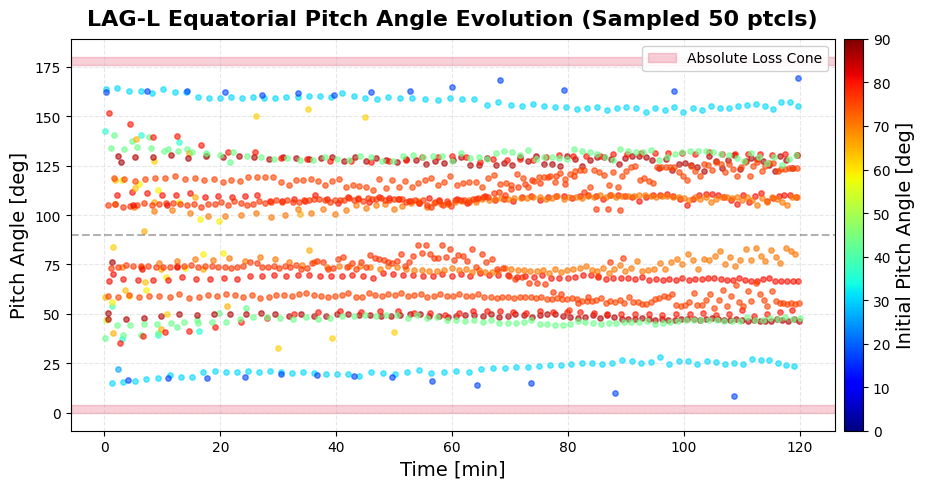

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Conservation.png


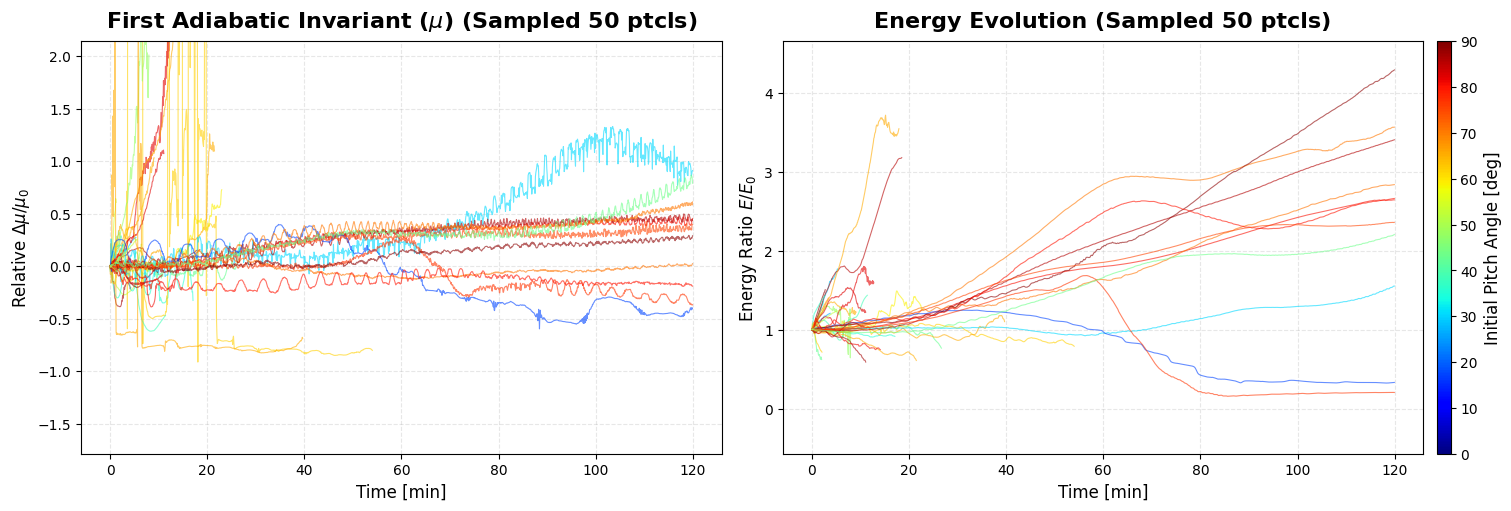

Standardizing Lorentz Grid to match GC...


/var/folders/p5/ymqv5gy52216l52n9p6467640000gq/T/ipykernel_61509/945504258.py:406: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax3d.scatter(p_end[0], p_end[1], p_end[2], color=c, marker='x', s=20, edgecolors='k', lw=1.2, alpha=1.0, zorder=101)


Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Global_Trajectory_Lorentz_Final.png


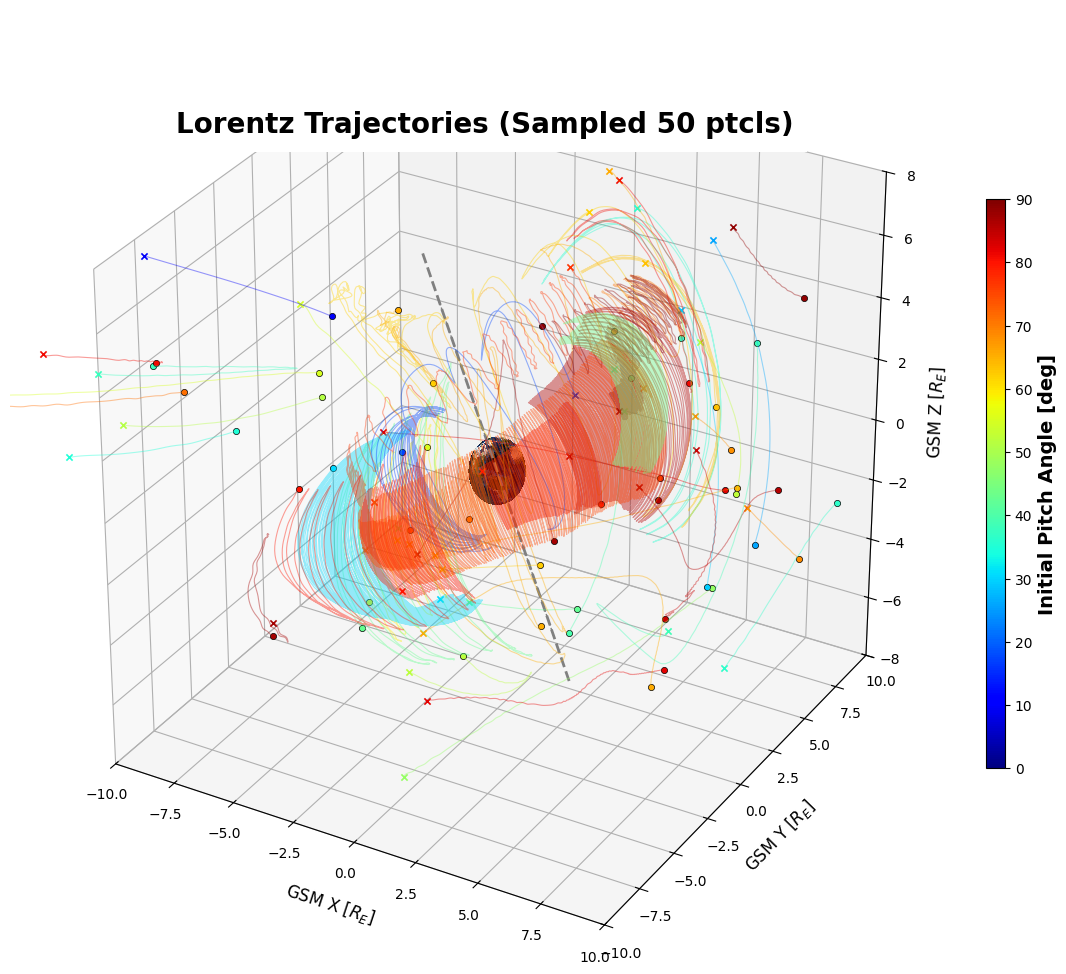

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Spherical_Components_Final.png


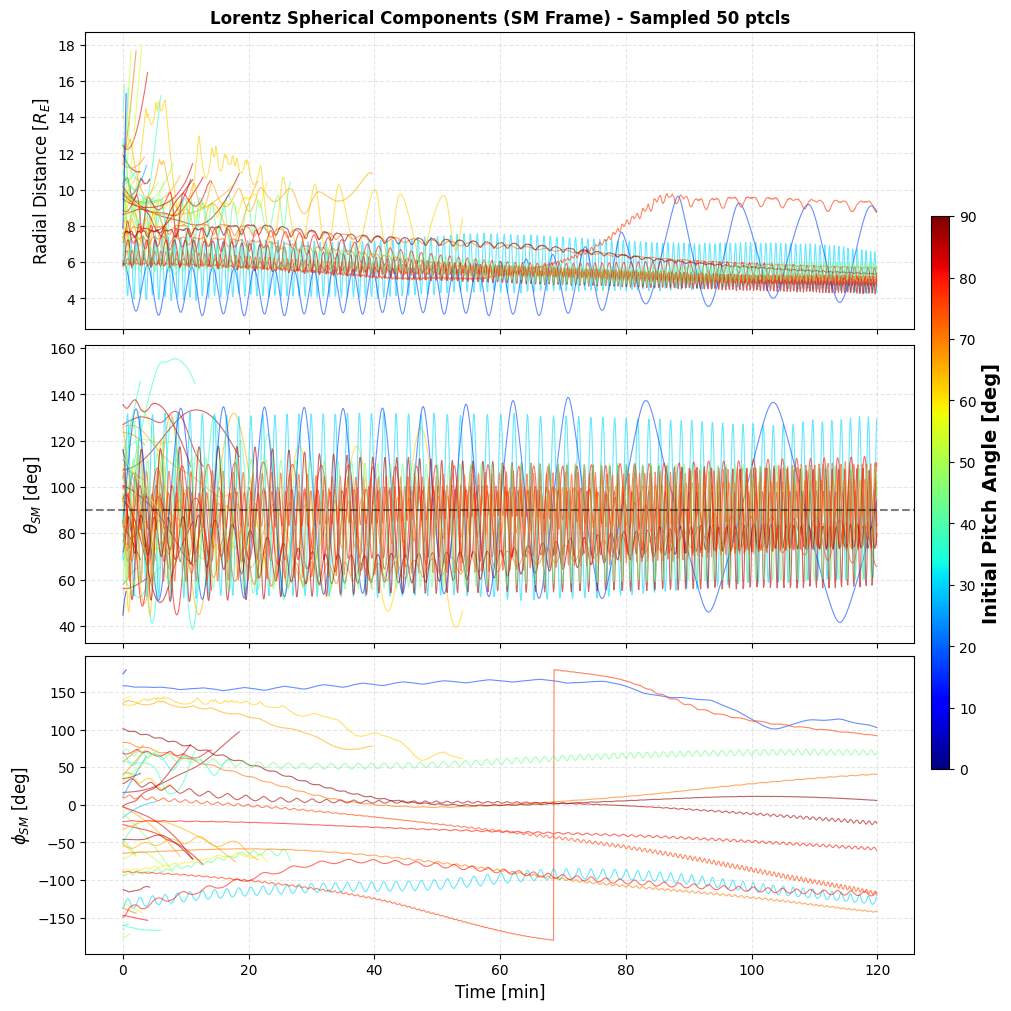

Rendering Tight Zoom (First 80 steps)...


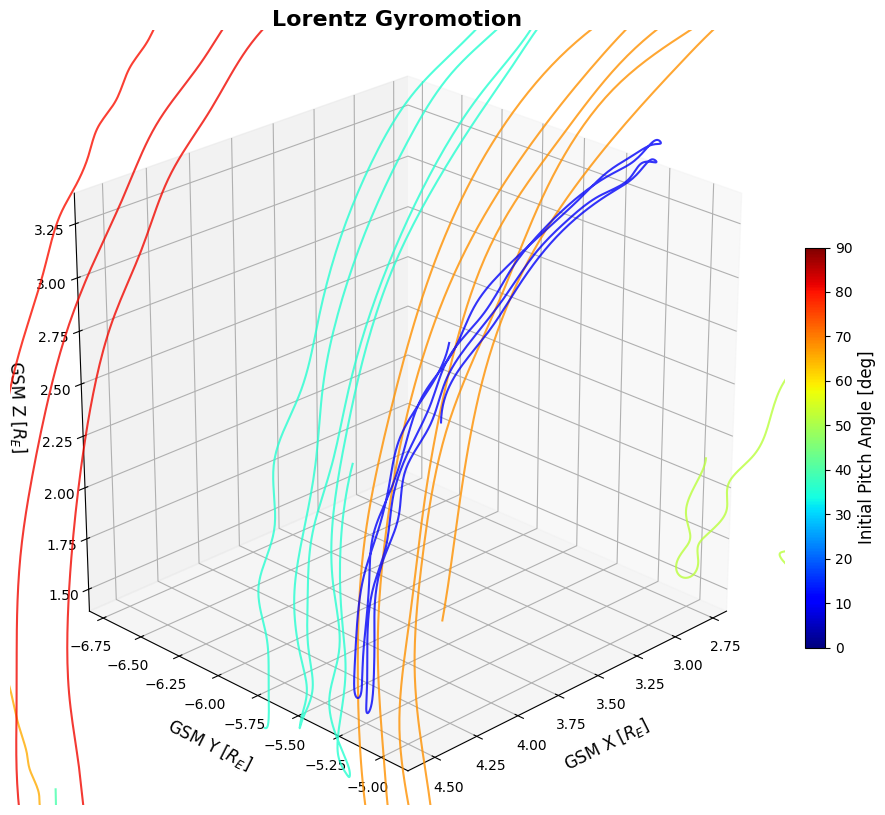

>> Loading GOES-18 orbit data from /Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf...
❌ Could not load orbit data (satellite will not be plotted): /Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf not found
Generating Density Evolution Plot (Downsampled to 8 panels)...


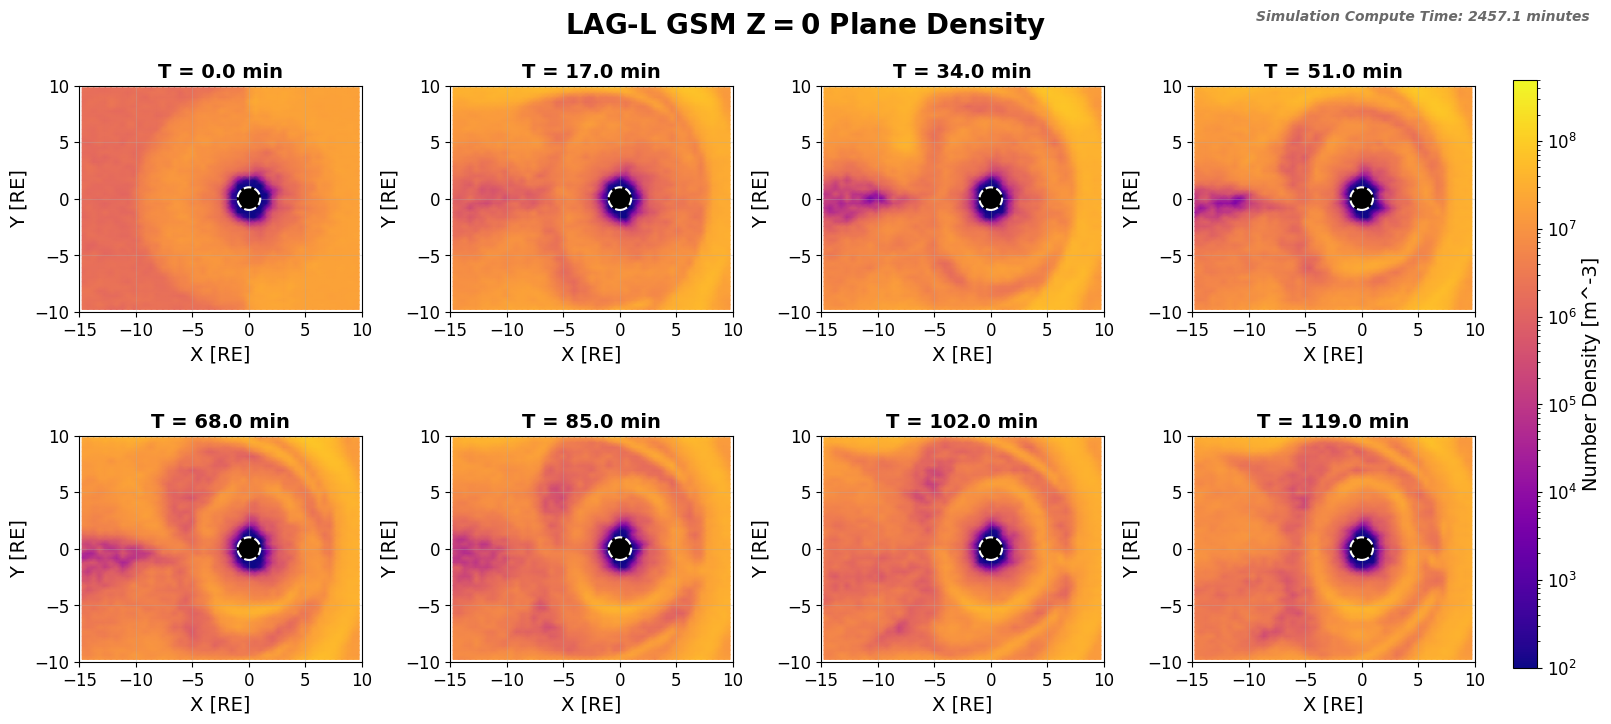

Generating 4-Panel Diagnostics from stored history...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Global_4Panel_Diagnostics.png


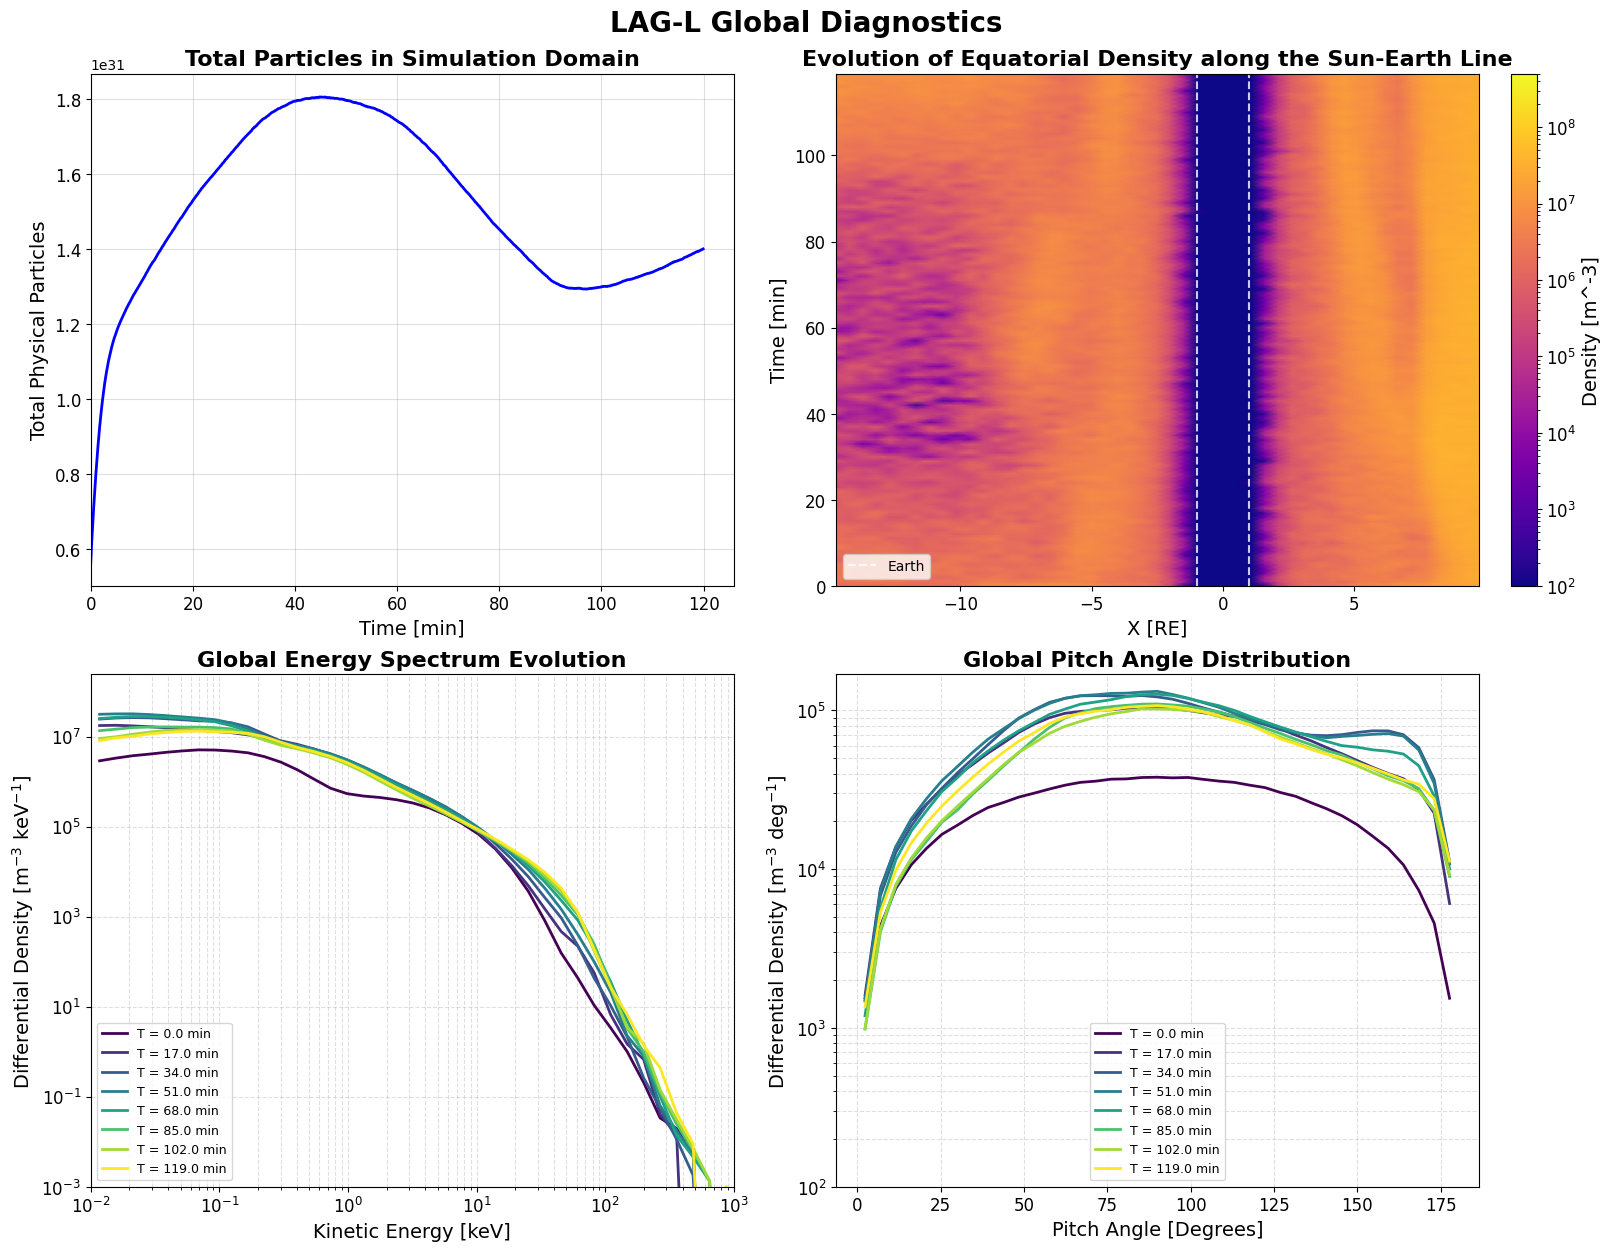

--- Running GOES-18 Virtual Satellite Validation ---
✅ Success! Forced the h5netcdf backend.
Loading MHD Background from saved CSV...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_GOES18_Validation_Virtual_Sat_Flux.png


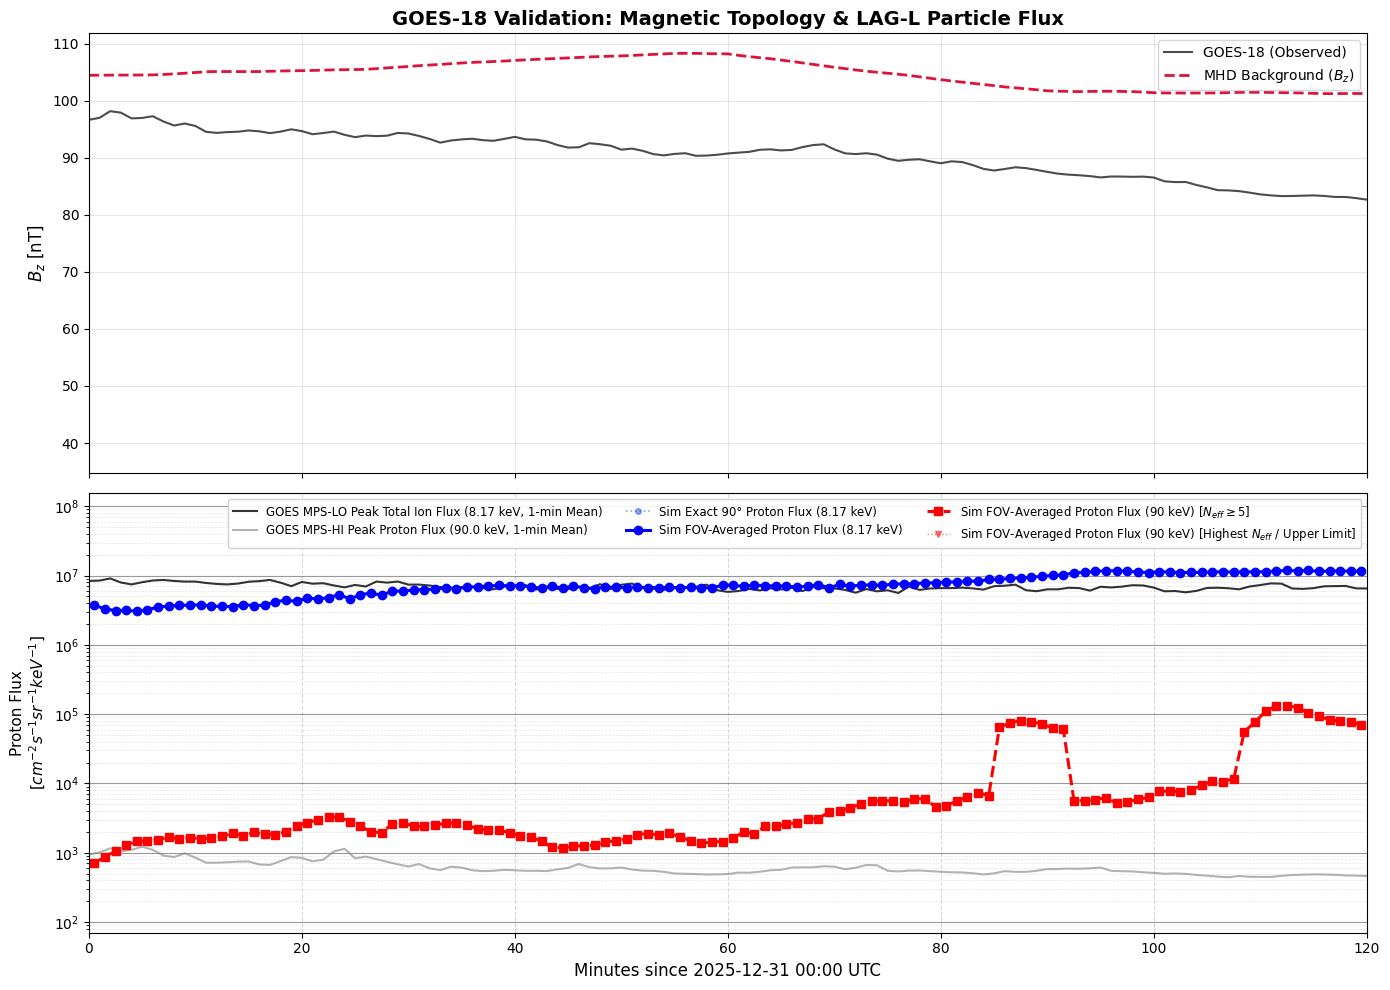

--- Generating Source-Resolved 90-keV Diagnostics ---
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_GOES18_90keV_Statistical_Diagnostics.png


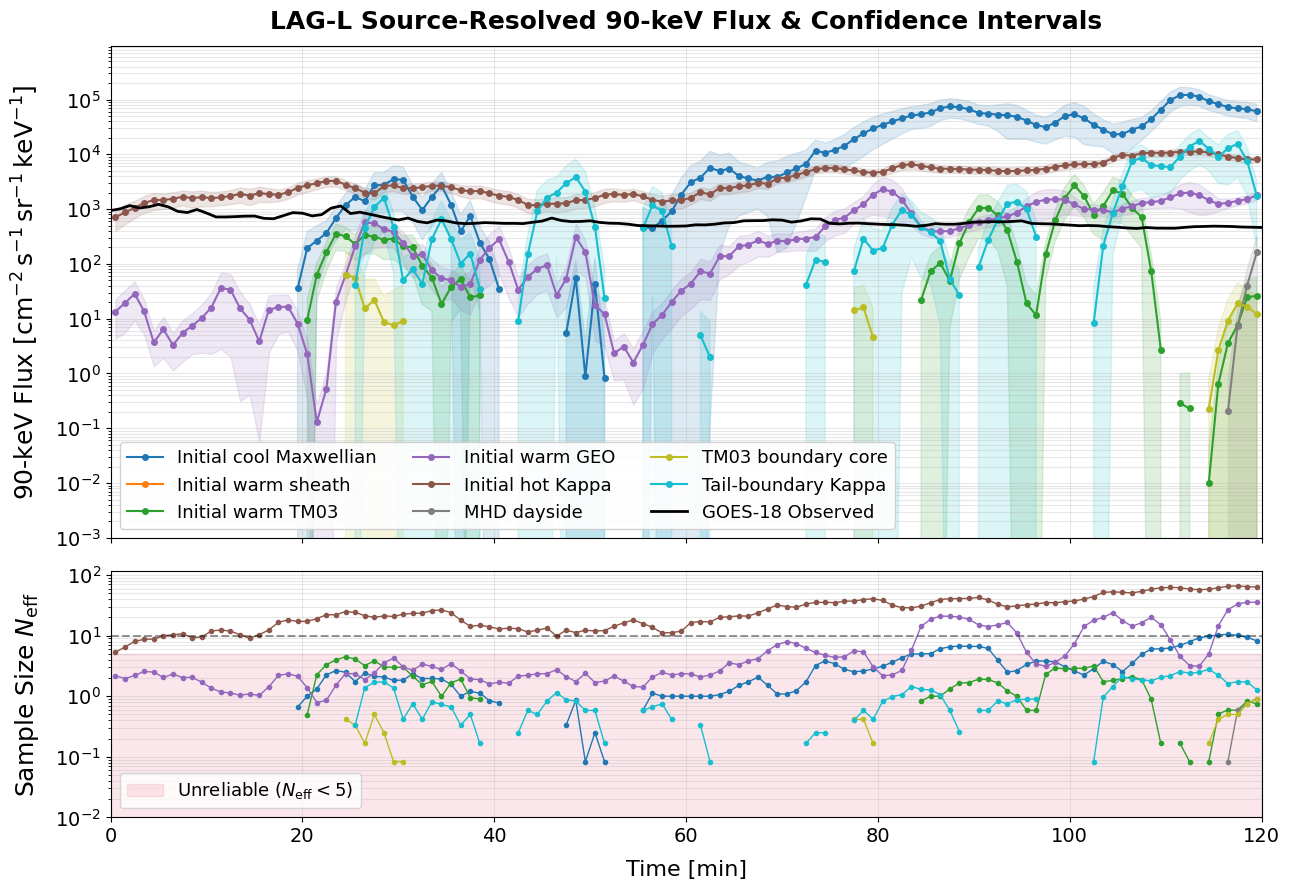

In [ ]:
import os
import glob
import pickle
import numpy as np
import xarray as xr
from xarray.backends import H5netcdfBackendEntrypoint
from datetime import datetime, timezone
import cdflib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patheffects as pe  # <-- ADDED for text outline
from matplotlib.colors import Normalize, LogNorm, LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from PIL import Image
from collections import defaultdict
import geopack.geopack as geopack
from scipy.ndimage import gaussian_filter
import matplotlib.ticker as ticker # <-- ADDED for log scale minor ticks
from scipy.interpolate import interp1d

# =============================================================================
# 1. CONSTANTS & DATA LOADING
# =============================================================================
RE = 6.371e6
sim_start_time = datetime(2025, 12, 31, 0, 0, 0)
sim_start_unix = sim_start_time.replace(tzinfo=timezone.utc).timestamp() 

# =============================================================================
# UNIVERSAL DENSITY SCALES (Ensures 1:1 cross-method comparison)
# =============================================================================
DENS_VMIN = 1e2   # Matches the bottom tick in the reference plot
DENS_VMAX = 5e8   # Matches the top extension of the reference colorbar

print(">> Searching for latest Lorentz simulation run...")
base_dir = "GIFs/FullLorentz"
run_folders = glob.glob(os.path.join(base_dir, "Run_*"))

if not run_folders:
    raise FileNotFoundError(f"No run folders found in {base_dir}!")

# Sort the folders by their modification time, oldest to newest
run_folders.sort(key=os.path.getmtime)

# Automatically grab the newest folder
latest_run_folder = run_folders[-1]
run_folder = latest_run_folder 
base_name = os.path.basename(run_folder).replace("Run_", "ProtonSim_Lorentz_")

# pkl_files = glob.glob(os.path.join(latest_run_folder, "*_plot_data.pkl"))
# if not pkl_files:
#     raise FileNotFoundError(f"No .pkl data file found in {latest_run_folder}")

# data_file_path = pkl_files[0]
data_file_path = "/Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/FullLorentz/LinuxRuns/Final/ProtonSim_Lorentz_20260929_132529_plot_data.pkl"
print(f">> Loading data from {data_file_path}...")

with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

# --- UNPACK VARIABLES ---
N_particles = data["N_particles"]
N_INITIAL_ACTIVE = data["N_INITIAL_ACTIVE"]
plot_indices = data["plot_indices"]
dt_eff = data["dt_eff"]
alphas = data["alphas"]
SPINUP_TIME = data["SPINUP_TIME"]
MAX_SIM_TIME = data["MAX_SIM_TIME"]

equator_crossings = data["equator_crossings"]

t_array = data["t_array"]
trajectory = data["trajectory"]
KE = data["KE"]
mu_rel = data["mu_rel"]

snapshot_times = data["snapshot_times"]
density_snapshots = data["density_snapshots"]
dens_x_edges = data["dens_x_edges"]
dens_y_edges = data["dens_y_edges"]
global_time_history = data["global_time_history"]
global_mass_history = data["global_mass_history"]
energy_spectra = data["energy_spectra"]
pitch_spectra = data["pitch_spectra"]
e_bins = data["e_bins"]
alpha_bins = data["alpha_bins"]

# Safely load the new Peak and 90-Degree reference arrays from the pickle file
goes_snap_flux_10keV_90 = data.get("goes_snap_flux_10keV_90", np.full(len(snapshot_times), np.nan))
goes_snap_flux_90keV_90 = data.get("goes_snap_flux_90keV_90", np.full(len(snapshot_times), np.nan))
goes_snap_flux_10keV_peak = data.get("goes_snap_flux_10keV_peak", np.full(len(snapshot_times), np.nan))
goes_snap_flux_90keV_peak = data.get("goes_snap_flux_90keV_peak", np.full(len(snapshot_times), np.nan))

# --- ADD THESE MISSING LINES TO YOUR UNPACKING BLOCK ---
goes_1min_flux_90_all_sources = data.get("goes_1min_flux_90_all_sources", np.full(len(snapshot_times), np.nan))

# Source-resolved data for 4-panel diagnostics
SOURCE_NAMES = data.get("SOURCE_NAMES", [])
goes_flux_90_by_source = data.get("goes_flux_90_by_source", None)
goes_raw_count_90_by_source = data.get("goes_raw_count_90_by_source", None)
goes_neff_90_by_source = data.get("goes_neff_90_by_source", None)
goes_maxfrac_90_by_source = data.get("goes_maxfrac_90_by_source", None)
# -------------------------------------------------------

print(">> Data loaded successfully!")


# =============================================================================
# 2. HELPER FUNCTIONS & GLOBAL STYLING
# =============================================================================
def fast_norm(v):
    return np.linalg.norm(v)

def get_ephemeris_params(time_input):
    """Calculates Earth's rotation vector and Dipole Axis in GSM."""
    d2r = np.pi / 180.0
    OMEGA_MAG = 7.2921159e-5

    ut_timestamp = time_input.replace(tzinfo=timezone.utc).timestamp()
    geopack.recalc(ut_timestamp)
    
    lat_rad, lon_rad = 79.6 * d2r, 280.6 * d2r
    M_geo = np.array([np.cos(lat_rad)*np.cos(lon_rad), np.cos(lat_rad)*np.sin(lon_rad), np.sin(lat_rad)])
    omega_geo = np.array([0.0, 0.0, 1.0])

    y, m, d = time_input.year, time_input.month, time_input.day
    h_utc = time_input.hour + time_input.minute/60 + time_input.second/3600
    jd = 367*y - int(7*(y + int((m+9)/12))/4) + int(275*m/9) + d + 1721013.5 + h_utc/24
    T_0 = (jd - 2451545.0) / 36525.0

    L0 = (280.46646 + 36000.76983 * T_0) % 360
    M_anom = (357.52911 + 35999.05029 * T_0) % 360
    lambda_sun = (L0 + 1.914602 * np.sin(M_anom * d2r) + 0.019993 * np.sin(2 * M_anom * d2r)) * d2r
    epsilon = (23.439291 - 0.0130042 * T_0) * d2r
    S_gei = np.array([np.cos(lambda_sun), np.cos(epsilon)*np.sin(lambda_sun), np.sin(epsilon)*np.sin(lambda_sun)])

    theta_GST = (100.46061815 + 36000.77005361 * T_0 + 360.98564724 * (jd - 2451545.0)) % 360 
    th_rad = theta_GST * d2r
    cos_th, sin_th = np.cos(th_rad), np.sin(th_rad)
    S_geo = np.array([S_gei[0]*cos_th + S_gei[1]*sin_th, -S_gei[0]*sin_th + S_gei[1]*cos_th, S_gei[2]])
    S_geo /= np.sqrt(S_geo[0]**2 + S_geo[1]**2 + S_geo[2]**2)

    X_gsm = S_geo 
    Y_gsm = np.cross(M_geo, S_geo); Y_gsm /= np.sqrt(Y_gsm[0]**2 + Y_gsm[1]**2 + Y_gsm[2]**2)
    Z_gsm = np.cross(X_gsm, Y_gsm)
    basis_gsm = np.vstack([X_gsm, Y_gsm, Z_gsm])

    return OMEGA_MAG * (basis_gsm @ omega_geo), basis_gsm @ M_geo

omega_earth_gsm, M_vec_gsm = get_ephemeris_params(sim_start_time)

# --- ADD GLOBAL PLOT STYLING ---
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'axes.labelweight': 'normal', 
    'figure.titleweight': 'bold',
    'font.weight': 'normal'
})

def apply_fmt(ax, title="", x="", ylabel="", grid=True, legend=False, title_size=14, label_size=12, tick_size=10):
    ax.set_title(title, fontsize=title_size, pad=10)
    ax.set_xlabel(x, fontsize=label_size, fontweight='normal')
    ax.set_ylabel(ylabel, fontsize=label_size, fontweight='normal')
    ax.tick_params(labelsize=tick_size)
    if grid: ax.grid(True, linestyle='--', alpha=0.3)
    if legend: ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', fontsize=10)

def setup_3d(ax, title, lim=15, title_size=16, label_size=12):
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
    ax.set_xlabel('GSM X [$R_E$]', fontsize=label_size, fontweight='normal', labelpad=8)
    ax.set_ylabel('GSM Y [$R_E$]', fontsize=label_size, fontweight='normal', labelpad=8)
    ax.set_zlabel('GSM Z [$R_E$]', fontsize=label_size, fontweight='normal', labelpad=8)
    if title:
        ax.set_title(title, fontsize=title_size, pad=5)
    ax.tick_params(labelsize=10)
    ax.set_box_aspect([1, 1, 1])

def save_plot(fig, descriptive_name):
    path = os.path.join(run_folder, f"{base_name}_{descriptive_name}.png")
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f"Saved: {path}")

def render_earth(ax, radius=1.0, res=4, tilt=0.0):
    user_home = os.path.expanduser("~")
    base_path_no_space = os.path.join(user_home, "Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/MHD_test_files/EarthSurfacePlots/Earth.jpg")
    base_path_with_space = os.path.join(user_home, "Library/CloudStorage/OneDrive - University of Florida/Research/Journal_Paper/MHD_test_files/EarthSurfacePlots/Earth.jpg")

    if os.path.exists(base_path_no_space): earth_img_path = base_path_no_space
    elif os.path.exists(base_path_with_space): earth_img_path = base_path_with_space
    else: earth_img_path = base_path_no_space.replace("Journal_Paper", "Journal Paper")

    try:
        pil_img = Image.open(earth_img_path).resize((400,200), Image.LANCZOS).convert("RGB")
        img = np.array(pil_img) / 255.0
        img_s = img[::res, ::res, :]
        
        lats = np.linspace(np.pi/2, -np.pi/2, img_s.shape[0]) 
        lons = np.linspace(-np.pi, np.pi, img_s.shape[1])
        lon, lat = np.meshgrid(lons, lats)
        
        x, y, z = radius * np.cos(lat) * np.cos(lon), radius * np.cos(lat) * np.sin(lon), radius * np.sin(lat)
        xr, zr = x * np.cos(tilt) + z * np.sin(tilt), -x * np.sin(tilt) + z * np.cos(tilt)
        
        surf = ax.plot_surface(xr, y, zr, rstride=1, cstride=1, facecolors=img_s, 
                               linewidth=0, antialiased=False, shade=False, zorder=0)
        try:
            surf.set_computed_zorder(False) 
        except AttributeError:
            pass
            
    except Exception as e:
        print(f"Warning: Using wireframe fallback. {e}")
        u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
        x = radius * np.cos(u) * np.sin(v)
        y = radius * np.sin(u) * np.sin(v)
        z = radius * np.cos(v)
        xr, zr = x * np.cos(tilt) + z * np.sin(tilt), -x * np.sin(tilt) + z * np.cos(tilt)
        ax.plot_wireframe(xr, y, zr, color="blue", alpha=0.3, zorder=0)

    dp_x, dp_z = 5.5 * np.sin(tilt), 5.5 * np.cos(tilt)
    ax.plot([dp_x, -dp_x], [0, 0], [dp_z, -dp_z], color='gray', ls='--', lw=1, zorder=5)

# Setup Colors
try: pitch_vals = np.degrees(alphas)
except: pitch_vals = np.linspace(0, 90, N_particles)
norm = Normalize(vmin=0, vmax=90)
cmap = cm.jet
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# =============================================================================
# 3. Equator Crossings (Lorentz - Standardized to GC Format)
# =============================================================================
if equator_crossings:
    print(f"Plotting equator crossings for {len(equator_crossings)} events...")
    
    crossings_by_id = defaultdict(list)
    for c in equator_crossings:
        crossings_by_id[c['id']].append(c)

    fig_eq, ax = plt.subplots(figsize=(10, 5))
    
    all_lc = [c['lc'] for c in equator_crossings]
    if all_lc:
        absolute_lc = np.min(all_lc)
        ax.axhspan(0, absolute_lc, color='crimson', alpha=0.2, label='Absolute Loss Cone')
        ax.axhspan(180-absolute_lc, 180, color='crimson', alpha=0.2)

    pids_to_plot = [pid for pid in plot_indices if pid in crossings_by_id]

    for pid in pids_to_plot:
        events = crossings_by_id[pid]
        events.sort(key=lambda x: x['time'])
        
        # <-- CHANGED TO MINUTES: x['time'] / 60.0 -->
        times = [x['time'] / 60.0 for x in events]
        pitch = [x['pitch'] for x in events]
        
        c = cmap(norm(pitch_vals[pid])) 
        ax.scatter(times, pitch, color=c, s=15, alpha=0.6)

    ax.axhline(90, color='k', ls='--', alpha=0.3)
    
    num_plotted = len(pids_to_plot)
    
    # <-- CHANGED TO MINUTES: "Time [min]" -->
    apply_fmt(ax, f"LAG-L Equatorial Pitch Angle Evolution (Sampled {len(plot_indices)} ptcls)", 
              "Time [min]", "Pitch Angle [deg]", title_size=16, label_size=14, tick_size=10, legend=True)

    cbar = fig_eq.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Initial Pitch Angle [deg]', fontsize=14)

    fig_eq.tight_layout()
    save_plot(fig_eq, "Equator_Crossings_Lorentz")
    plt.show()

# =============================================================================
# 4. Conservation & Dynamics (Memory Safe & Robust Zoom)
# =============================================================================
fig_cons, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

KE_norm = np.zeros_like(KE)
safe_E0 = np.where(KE[0, :] > 0, KE[0, :], 1.0)
KE_norm = KE / safe_E0

valid_mu_vals = []
valid_ke_vals = []

for tracked_idx, original_idx in enumerate(plot_indices):
    dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
    death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
    
    if death_step < 2: continue 
    
    if t_array.ndim == 2:
        t_plot = t_array[:death_step, tracked_idx]
    else:
        t_plot = t_array[:death_step]

    mu_line = mu_rel[:death_step, tracked_idx]
    ke_line = KE_norm[:death_step, tracked_idx]
    
    c = cmap(norm(pitch_vals[original_idx]))
    
    # <-- CHANGED TO MINUTES: t_plot / 60.0 -->
    axes[0].plot(t_plot / 60.0, mu_line, color=c, lw=0.8, alpha=0.6)
    axes[1].plot(t_plot / 60.0, ke_line, color=c, lw=0.8, alpha=0.6)

    valid_mu_vals.append(mu_line[::10])
    valid_ke_vals.append(ke_line[::10])

if valid_mu_vals:
    all_mu = np.concatenate(valid_mu_vals)
    sane_mu = all_mu[np.abs(all_mu) < 2.0] 
    
    if len(sane_mu) > 10:
        vmin, vmax = np.percentile(sane_mu, [1, 99])
        span = vmax - vmin
        if span == 0: span = 0.1
        axes[0].set_ylim(vmin - 0.5*span, vmax + 0.5*span)
    else:
        axes[0].set_ylim(-1, 1)

if valid_ke_vals:
    all_ke = np.concatenate(valid_ke_vals)
    sane_ke = all_ke[(all_ke > 0.1) & (all_ke < 5.0)]
    
    if len(sane_ke) > 10:
        kmin, kmax = np.percentile(sane_ke, [0.5, 99.5])
        if kmax == kmin: kmin -= 1e-5; kmax += 1e-5
        span = kmax - kmin
        axes[1].set_ylim(kmin - 0.2*span, kmax + 0.2*span)

axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useOffset=False)

# <-- CHANGED TO MINUTES: "Time [min]" -->
apply_fmt(axes[0], f"First Adiabatic Invariant ($\mu$) (Sampled {len(plot_indices)} ptcls)", 
          "Time [min]", r"Relative $\Delta \mu / \mu_0$", title_size=16, label_size=12, tick_size=10)
apply_fmt(axes[1], f"Energy Evolution (Sampled {len(plot_indices)} ptcls)", 
          "Time [min]", r"Energy Ratio $E/E_0$", title_size=16, label_size=12, tick_size=10)

cbar = fig_cons.colorbar(sm, ax=axes, pad=0.01, aspect=30)
cbar.set_label('Initial Pitch Angle [deg]', fontsize=12)

save_plot(fig_cons, "Conservation")
plt.show()

# =============================================================================
# 5. 3D Global Trajectory (Lorentz - Matched to GC Grid)
# =============================================================================
print("Standardizing Lorentz Grid to match GC...")
tilt_rad = geopack.psi
fig_3d = plt.figure(figsize=(14, 10)) 
ax3d = fig_3d.add_subplot(111, projection='3d')

render_earth(ax3d, tilt=tilt_rad, res=4) 

elev = ax3d.elev if ax3d.elev is not None else 30
azim = ax3d.azim if ax3d.azim is not None else -60
view_vector = np.array([np.cos(np.radians(elev))*np.cos(np.radians(azim)), 
                        np.cos(np.radians(elev))*np.sin(np.radians(azim)), 
                        np.sin(np.radians(elev))])
view_vector /= np.linalg.norm(view_vector)

for tracked_idx, original_idx in enumerate(plot_indices):
    dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
    death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
    if death_step < 5: continue 
    
    x_raw = trajectory[:death_step, tracked_idx, 0] / RE
    y_raw = trajectory[:death_step, tracked_idx, 1] / RE
    z_raw = trajectory[:death_step, tracked_idx, 2] / RE
    
    # --- Filter out any pre-spawn NaN padding before interpolating ---
    valid_mask = ~np.isnan(x_raw)
    if not np.any(valid_mask): continue
    
    x_c, y_c, z_c = x_raw[valid_mask], y_raw[valid_mask], z_raw[valid_mask]
    if len(x_c) < 2: continue
    
    t_orig = np.linspace(0, 1, len(x_c))
    t_smooth = np.linspace(0, 1, len(x_c) * 3) 
    x_s = interp1d(t_orig, x_c, kind='cubic')(t_smooth)
    y_s = interp1d(t_orig, y_c, kind='cubic')(t_smooth)
    z_s = interp1d(t_orig, z_c, kind='cubic')(t_smooth)

    pos_vecs = np.column_stack([x_s, y_s, z_s])
    dots = np.dot(pos_vecs, view_vector) 
    perp_dists_sq = np.sum(pos_vecs**2, axis=1) - dots**2 
    is_blocked = (dots < 0) & (perp_dists_sq < 0.98) 
    
    x_s[is_blocked] = np.nan; y_s[is_blocked] = np.nan; z_s[is_blocked] = np.nan
    c = cmap(norm(pitch_vals[original_idx]))

    ax3d.plot(x_s, y_s, z_s, color=c, lw=0.8, alpha=0.4, zorder=100)
    
    # Evaluate occlusion specifically for the true first and last physical coordinates
    p_start, p_end = np.array([x_c[0], y_c[0], z_c[0]]), np.array([x_c[-1], y_c[-1], z_c[-1]])
    b_start = (np.dot(p_start, view_vector) < 0) and (np.sum(p_start**2) - np.dot(p_start, view_vector)**2 < 0.98)
    b_end = (np.dot(p_end, view_vector) < 0) and (np.sum(p_end**2) - np.dot(p_end, view_vector)**2 < 0.98)

    if not b_start:
        ax3d.scatter(p_start[0], p_start[1], p_start[2], color=c, marker='o', s=20, edgecolors='k', lw=0.5, alpha=1.0, zorder=101)
    if not b_end:
        ax3d.scatter(p_end[0], p_end[1], p_end[2], color=c, marker='x', s=20, edgecolors='k', lw=1.2, alpha=1.0, zorder=101)

dp_len = 7.0
ax3d.plot([dp_len*np.sin(tilt_rad), -dp_len*np.sin(tilt_rad)], [0, 0], 
          [dp_len*np.cos(tilt_rad), -dp_len*np.cos(tilt_rad)], color='gray', ls='--', lw=2.0, zorder=50)

# Apply baseline 3D formatting but suppress the default title
setup_3d(ax3d, title=None) 

# 1. Set explicit asymmetric axis boundaries
ax3d.set_xlim(-10, 10)
ax3d.set_ylim(-10, 10)
ax3d.set_zlim(-8, 8)

# 2. Overlay a custom title with a white background block
ax3d.set_title(
    f'\n\n\nLorentz Trajectories (Sampled {len(plot_indices)} ptcls)', 
    fontsize=20, 
    y=.937,  # Adjust below 1.0 to pull the title down into the grid space
    bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=10, zorder=200)
)

cbar = fig_3d.colorbar(sm, ax=ax3d, shrink=0.6, aspect=30, pad=0.02)
cbar.set_label('Initial Pitch Angle [deg]', fontsize=14, fontweight='bold')

plt.tight_layout()
save_plot(fig_3d, "Global_Trajectory_Lorentz_Final")
plt.show()

# =============================================================================
# 6. Spherical Components (Cleaned)
# =============================================================================
z_sm = M_vec_gsm / fast_norm(M_vec_gsm)
y_sm = np.array([0.0, 1.0, 0.0])
x_sm = np.cross(y_sm, z_sm); x_sm /= fast_norm(x_sm)

xt_sm = np.tensordot(trajectory, x_sm, axes=([2],[0]))
yt_sm = np.tensordot(trajectory, y_sm, axes=([2],[0]))
zt_sm = np.tensordot(trajectory, z_sm, axes=([2],[0]))

r_sm = np.sqrt(xt_sm**2 + yt_sm**2 + zt_sm**2) / RE
th_sm = np.degrees(np.arccos(np.clip(zt_sm / (r_sm*RE + 1e-5), -1, 1)))
ph_sm = np.degrees(np.arctan2(yt_sm, xt_sm))

fig_sm, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)
labels = [r'Radial Distance [$R_E$]', r'$\theta_{SM}$ [deg]', r'$\phi_{SM}$ [deg]']
data_list = [r_sm, th_sm, ph_sm]

for ax_idx, (ax, plot_data, lbl) in enumerate(zip(axes, data_list, labels)):
    for tracked_idx, original_idx in enumerate(plot_indices):
        dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
        death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
        if death_step < 2: continue
            
        if t_array.ndim == 2: t_plot = t_array[:death_step, tracked_idx]
        else: t_plot = t_array[:death_step]
            
        line_plot = plot_data[:death_step, tracked_idx].copy()
            
        # <-- CHANGED TO MINUTES: t_plot / 60.0 -->
        ax.plot(t_plot / 60.0, line_plot, color=cmap(norm(pitch_vals[original_idx])), lw=0.8, alpha=0.6)
    apply_fmt(ax, ylabel=lbl)

axes[0].set_title(f"Lorentz Spherical Components (SM Frame) - Sampled {len(plot_indices)} ptcls", fontsize=12)
axes[1].axhline(90, color='k', ls='--', alpha=0.5, label='Mag. Equator')
# <-- CHANGED TO MINUTES: "Time [min]" -->
axes[-1].set_xlabel("Time [min]")

cbar = fig_sm.colorbar(sm, ax=axes, shrink=0.6, aspect=30, pad=0.02)
cbar.set_label('Initial Pitch Angle [deg]', fontsize=14, fontweight='bold')

save_plot(fig_sm, "Spherical_Components_Final")
plt.show()

# =============================================================================
# 7. Initial Motion Detail (Tight Zoomed Gyromotion) 
# =============================================================================
fig_zoom = plt.figure(figsize=(10, 10))
ax_z = fig_zoom.add_subplot(111, projection='3d')

zoom_steps = 80  
z_end = min(zoom_steps, trajectory.shape[0])

print(f"Rendering Tight Zoom (First {z_end} steps)...")

all_x, all_y, all_z = [], [], []

for tracked_idx, original_idx in enumerate(plot_indices):
    dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
    death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
    if death_step < 5: continue
    
    end_idx = min(z_end, death_step)
    x_raw = trajectory[:end_idx, tracked_idx, 0] / RE
    y_raw = trajectory[:end_idx, tracked_idx, 1] / RE
    z_raw = trajectory[:end_idx, tracked_idx, 2] / RE
    
    all_x.append(x_raw)
    all_y.append(y_raw)
    all_z.append(z_raw)

if all_x:
    focus_idx = np.random.randint(0, len(all_x))
    f_x, f_y, f_z = all_x[focus_idx], all_y[focus_idx], all_z[focus_idx]
    mid_x, mid_y, mid_z = np.mean(f_x), np.mean(f_y), np.mean(f_z)

    fixed_span = 1.0 
    
    ax_z.set_xlim(mid_x - fixed_span, mid_x + fixed_span)
    ax_z.set_ylim(mid_y - fixed_span, mid_y + fixed_span)
    ax_z.set_zlim(mid_z - fixed_span, mid_z + fixed_span)

    for i, (rx, ry, rz) in enumerate(zip(all_x, all_y, all_z)):
        t_orig = np.linspace(0, 1, len(rx))
        t_smooth = np.linspace(0, 1, len(rx) * 10)
        xs = interp1d(t_orig, rx, kind='cubic')(t_smooth)
        ys = interp1d(t_orig, ry, kind='cubic')(t_smooth)
        zs = interp1d(t_orig, rz, kind='cubic')(t_smooth)
        
        original_idx = plot_indices[i]
        ax_z.plot(xs, ys, zs, color=cmap(norm(pitch_vals[original_idx])), lw=1.5, alpha=0.8)

ax_z.set_box_aspect([1, 1, 1]) 

cbar_ax = fig_zoom.add_axes([0.92, 0.3, 0.02, 0.4])
fig_zoom.colorbar(sm, cax=cbar_ax)
cbar_ax.set_ylabel('Initial Pitch Angle [deg]', fontsize=12)

ax_z.set_xlabel('GSM X [$R_E$]', fontsize=12, fontweight='normal', labelpad=8)
ax_z.set_ylabel('GSM Y [$R_E$]', fontsize=12, fontweight='normal', labelpad=8)
ax_z.set_zlabel('GSM Z [$R_E$]', fontsize=12, fontweight='normal', labelpad=8)
ax_z.set_title(f"Lorentz Gyromotion", fontsize=16, pad=0)
ax_z.tick_params(labelsize=10)

ax_z.view_init(elev=25, azim=45)
fig_zoom.subplots_adjust(top=0.95)

plt.show()

# =========================================================
# ORBIT DATA LOADING (ADDED FOR SATELLITE POSITION)
# =========================================================
orbit_file = "/Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf"
print(f">> Loading GOES-18 orbit data from {orbit_file}...")

try:
    orbit_cdf = cdflib.CDF(orbit_file)
    orbit_epoch = orbit_cdf.varget("Epoch")
    orbit_times_unix = cdflib.cdfepoch.unixtime(orbit_epoch)
    
    try:
        orbit_xyz = orbit_cdf.varget("XYZ_GSM")
    except ValueError:
        orbit_xyz = orbit_cdf.varget("XYZ_GSE")
        
    if np.nanmax(np.abs(orbit_xyz)) > 100:
        orbit_xyz = orbit_xyz / 6371.2
        
    print(">> Orbit data loaded successfully.")
except Exception as e:
    print(f"❌ Could not load orbit data (satellite will not be plotted): {e}")
    orbit_times_unix = None
    orbit_xyz = None

# =============================================================================
# 8. DENSITY PLOTTING (Downsampled to 8 Panels)
# =============================================================================
if len(density_snapshots) > 0:
    print("Generating Density Evolution Plot (Downsampled to 8 panels)...")

    compute_str = f"Simulation Compute Time: {data.get('compute_time_minutes', 0.0):.1f} minutes"
    
    n_snaps = len(density_snapshots)
    target_panels = 8
    
    # Generate exactly 8 indices spanning from the first to the last frame safely
    if n_snaps > target_panels:
        dens_indices = np.linspace(0, n_snaps - 1, target_panels, dtype=int)
    else:
        dens_indices = np.arange(n_snaps)
        
    cols = 4
    rows = int(np.ceil(len(dens_indices) / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows), constrained_layout=True)
    if rows == 1: axes = np.expand_dims(axes, axis=0)
    ax_flat = axes.flatten()
    
    x_centers = (dens_x_edges[:-1] + dens_x_edges[1:]) / 2.0 / RE
    y_centers = (dens_y_edges[:-1] + dens_y_edges[1:]) / 2.0 / RE
    
    max_val = max(1e3, np.max([s['density'].max() for s in density_snapshots]))
    
    for idx_count, snap_idx in enumerate(dens_indices):
        ax = ax_flat[idx_count]
        snap = density_snapshots[snap_idx]
        dens_2d = snap['density']
        
        im = ax.pcolormesh(x_centers, y_centers, dens_2d.T, 
                           shading='gouraud', cmap='plasma', 
                           norm=LogNorm(vmin=DENS_VMIN, vmax=DENS_VMAX))
        
        earth_mask = plt.Circle((0, 0), 1.0, color='black', zorder=10)
        earth_outline = plt.Circle((0, 0), 1.0, color='white', fill=False, linestyle='--', linewidth=1.5, zorder=11)
        ax.add_patch(earth_mask)
        ax.add_patch(earth_outline)
        
        # Plot Orbit Path and Satellite Position
        if orbit_times_unix is not None and orbit_xyz is not None:
            snap_unix = sim_start_unix + snap['time']
            half_day = 12 * 3600
            time_mask = (orbit_times_unix >= snap_unix - half_day) & (orbit_times_unix <= snap_unix + half_day)
            
            ax.plot(orbit_xyz[time_mask, 0], orbit_xyz[time_mask, 1], 
                    color='black', linestyle='--', linewidth=1.5, zorder=12, alpha=0.8,
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])
            
            sat_x = np.interp(snap_unix, orbit_times_unix, orbit_xyz[:, 0])
            sat_y = np.interp(snap_unix, orbit_times_unix, orbit_xyz[:, 1])
            
            ax.plot(sat_x, sat_y, marker='*', color='white', markersize=12, markeredgecolor='black', zorder=15)
            ax.text(sat_x + 0.4, sat_y + 0.4, 'GOES-18', color='white', fontsize=9, fontweight='bold', zorder=15,
                    path_effects=[pe.withStroke(linewidth=2, foreground="black")])
        
        ax.set_title(f"T = {snap['time'] / 60.0:.1f} min", fontsize=14, fontweight='bold')
        ax.set_xlabel("X [RE]", fontsize=14)
        ax.set_ylabel("Y [RE]", fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-10, 10)
        ax.set_xlim(-15, 10)

    # Hide any remaining empty subplots
    for empty_idx in range(len(dens_indices), len(ax_flat)):
        ax_flat[empty_idx].set_visible(False)

    # --- UPDATED COLORBAR (Taller, wider, and larger text) ---
    cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.85, aspect=25, pad=0.02)
    cbar.set_label("Number Density [m^-3]", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    plt.suptitle("LAG-L GSM $\mathbf{Z=0}$ Plane Density", fontsize=20, y=1.02)

    fig.text(0.99, 1.02, compute_str, ha='right', va='top', 
             fontsize=10, color='dimgray', style='italic', weight='bold')
    
    path = os.path.join(run_folder, "Lorentz_Density.png")
    fig.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()

# =============================================================================
# 9. Comparison Diagnostic Plot (Post-Processed from Tracker History)
# =============================================================================
if len(density_snapshots) > 0:
    print("Generating 4-Panel Diagnostics from stored history...")
    fig2, axs = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

    times_min = np.array([s['time'] / 60.0 for s in density_snapshots])

    t_plot_mass = np.array(global_time_history) / 60.0
    true_total_mass = np.array(global_mass_history)

    axs[0,0].plot(t_plot_mass, true_total_mass, 'b-', linewidth=2) 
    axs[0,0].set_xlim(left=-SPINUP_TIME / 60.0) 
    
    axs[0,0].set_title("Total Particles in Simulation Domain", fontweight='bold', fontsize=16)
    axs[0,0].set_xlabel("Time [min]", fontsize=14)
    axs[0,0].set_ylabel("Total Physical Particles", fontsize=14)
    axs[0,0].tick_params(labelsize=12)
    axs[0,0].grid(True, alpha=0.4)

    x_centers = (dens_x_edges[:-1] + dens_x_edges[1:]) / 2.0 / RE
    y_centers = (dens_y_edges[:-1] + dens_y_edges[1:]) / 2.0 / RE
    y_mid_idx = np.argmin(np.abs(y_centers)) 

    hov_data = np.array([snap['density'][:, y_mid_idx] for snap in density_snapshots])
    hov_masked = np.ma.masked_invalid(hov_data)
    max_dens = np.max(hov_masked) if len(hov_masked) > 0 else 1e6

    im_hov = axs[0,1].pcolormesh(x_centers, times_min, hov_masked, 
                                 shading='gouraud', cmap='plasma', 
                                 norm=LogNorm(vmin=DENS_VMIN, vmax=DENS_VMAX))
                                 
    axs[0,1].axvline(x=1.0, color='w', linestyle='--', alpha=0.8, label='Earth')
    axs[0,1].axvline(x=-1.0, color='w', linestyle='--', alpha=0.8)
    axs[0,1].set_title("Evolution of Equatorial Density along the Sun-Earth Line", fontweight='bold', fontsize=16)
    axs[0,1].set_xlabel("X [RE]", fontsize=14)
    axs[0,1].set_ylabel("Time [min]", fontsize=14)
    axs[0,1].tick_params(labelsize=12)
    
    cbar_hov = fig2.colorbar(im_hov, ax=axs[0,1])
    cbar_hov.set_label('Density [m^-3]', fontsize=14)
    cbar_hov.ax.tick_params(labelsize=12)
    axs[0,1].legend(loc='lower left', fontsize=10)

    # Panels 3 & 4: Spectra setup
    e_centers = (e_bins[:-1] + e_bins[1:]) / 2.0
    alpha_centers = (alpha_bins[:-1] + alpha_bins[1:]) / 2.0

    n_snaps = len(density_snapshots)
    target_lines = 8
    if n_snaps > target_lines:
        spectra_indices = np.linspace(0, n_snaps - 1, target_lines, dtype=int)
    else:
        spectra_indices = np.arange(n_snaps)

    num_lines = len(spectra_indices)
    colors_lines = plt.cm.viridis(np.linspace(0, 1, num_lines))

    for color, k in zip(colors_lines, spectra_indices):
        snap = density_snapshots[k]
        t_target = snap['time']
        t_label = f"T = {t_target/60.0:.1f} min"

        scaled_E = energy_spectra[k]
        scaled_alpha = pitch_spectra[k]

        axs[1,0].plot(e_centers, scaled_E + 1e-10, color=color, label=t_label, linewidth=2)
        axs[1,1].plot(alpha_centers, scaled_alpha + 1e-10, color=color, label=t_label, linewidth=2)

    axs[1,0].set_xscale('log')
    axs[1,0].set_yscale('log')
    axs[1,0].set_title("Global Energy Spectrum Evolution", fontweight='bold', fontsize=16)
    axs[1,0].set_xlabel("Kinetic Energy [keV]", fontsize=14)
    axs[1,0].set_ylabel("Differential Density [m$^{-3}$ keV$^{-1}$]", fontsize=14)
    axs[1,0].tick_params(labelsize=12)
    axs[1,0].grid(True, which="both", ls="--", alpha=0.4)
    axs[1,0].set_xlim(0.01, 1000) 
    axs[1,0].set_ylim(bottom=1e-3) 
    axs[1,0].legend(fontsize=9, loc='lower left', ncol=2 if num_lines > 10 else 1)

    axs[1,1].set_yscale('log')
    axs[1,1].set_title("Global Pitch Angle Distribution", fontweight='bold', fontsize=16)
    axs[1,1].set_xlabel("Pitch Angle [Degrees]", fontsize=14)
    axs[1,1].set_ylabel("Differential Density [m$^{-3}$ deg$^{-1}$]", fontsize=14)
    axs[1,1].tick_params(labelsize=12)
    axs[1,1].set_ylim(bottom=100) 
    axs[1,1].grid(True, which="both", ls="--", alpha=0.4)
    axs[1,1].legend(fontsize=9, loc='lower center', ncol=2 if num_lines > 10 else 1)
    
    plt.suptitle("LAG-L Global Diagnostics", fontsize=20, y=1.03)

    save_plot(fig2, "Global_4Panel_Diagnostics")
    plt.show()

# =============================================================================
# 10. VIRTUAL SATELLITE VALIDATION (GOES-18 vs Lorentz Particles)
# =============================================================================
print("--- Running GOES-18 Virtual Satellite Validation ---")

base_dir = "goes_data/goes18"
mag_file = f"{base_dir}/l2/data/magn-l2-avg1m/2025/12/dn_magn-l2-avg1m_g18_d20251231_v2-0-4.nc"
mpsh_file = f"{base_dir}/l2/data/mpsh-l2-avg1m/2025/12/ops_seis-l1b-mpsh_g18_d20251231_v0-0-0.nc"
mpsl_file = f"{base_dir}/l2/data/mpsl-l2-avg1m/2025/12/ops_seis-l1b-mpsl_g18_d20251231_v0-0-0.nc"

try:
    ds_mag = xr.open_dataset(mag_file, engine=H5netcdfBackendEntrypoint)
    ds_mpsh = xr.open_dataset(mpsh_file, engine=H5netcdfBackendEntrypoint)
    ds_mpsl = xr.open_dataset(mpsl_file, engine=H5netcdfBackendEntrypoint)
    print("✅ Success! Forced the h5netcdf backend.")
except Exception as e:
    print(f"❌ Could not load GOES data. Make sure files are present.\nError: {e}")
    ds_mag = xr.Dataset({'b_gsm': (['time', 'dim'], np.zeros((1, 3))), 'time': [0]})
    ds_mpsh = xr.Dataset({'AvgDiffProtonFlux': (['time', 'dim'], np.zeros((1, 1))), 'time': [0]})
    ds_mpsl = xr.Dataset({'DiffIonFluxes': (['time', 'dim'], np.zeros((1, 11))), 'time': [0]})

obs_times_unix = ds_mag['time'].values.astype('datetime64[s]').astype(np.float64)
t_sync_norm = obs_times_unix - sim_start_unix

obs_bz = ds_mag['b_gsm'].values[:, 2]

# ---------------------------------------------------------
# --- GOES SATELLITE DATA FIX: DIRECTIONAL PEAK & mean ---
# ---------------------------------------------------------
# 1. MPS-HI (~90 keV): Extract directional L1b variable and find the peak telescope
flux_hi_raw = ds_mpsh['DiffProtonFluxes'].values
flux_hi_peak = np.nanmax(flux_hi_raw, axis=1) if flux_hi_raw.ndim == 3 else flux_hi_raw

start_dt64 = np.datetime64('2025-12-31T00:00:00')
l1b_time_hi = start_dt64 + np.arange(flux_hi_peak.shape[0]) * np.timedelta64(1, 's')
da_flux_hi = xr.DataArray(flux_hi_peak, coords={'time': l1b_time_hi}, dims=['time', 'energy'])
da_flux_hi_1min = da_flux_hi.resample(time='1Min').mean()

obs_flux_hi = da_flux_hi_1min.values[:, 0] 
obs_flux_hi_times_unix = da_flux_hi_1min['time'].values.astype('datetime64[s]').astype(np.float64)

# 2. MPS-LO (~8.17 keV): Find peak zone and apply 1-minute mean
flux_lo_raw = ds_mpsl['DiffIonFluxes'].values
flux_lo_peak = np.nanmax(flux_lo_raw, axis=1) if flux_lo_raw.ndim == 3 else flux_lo_raw

l1b_time_lo = start_dt64 + np.arange(flux_lo_peak.shape[0]) * np.timedelta64(1, 's')
da_flux_lo = xr.DataArray(flux_lo_peak, coords={'time': l1b_time_lo}, dims=['time', 'energy'])
da_flux_lo_1min = da_flux_lo.resample(time='1Min').mean()

# Shifted to index 11 (8.17 keV) to accurately match the 10 keV simulation outputs
obs_flux_lo = da_flux_lo_1min.values[:, 11] if da_flux_lo_1min.values.shape[1] > 11 else np.zeros_like(da_flux_lo_1min.values[:, 0])
obs_flux_lo_times_unix = da_flux_lo_1min['time'].values.astype('datetime64[s]').astype(np.float64)

print("Loading MHD Background from saved CSV...")
bz_csv_path = os.path.join(run_folder, "model_B_bz.csv")
try:
    bz_data = np.loadtxt(bz_csv_path, delimiter=",", skiprows=1)
    csv_t_axis_min = bz_data[:, 0]
    model_bz = bz_data[:, 1]
except FileNotFoundError:
    print(f"Warning: {bz_csv_path} not found. Skipping model_bz plot line.")
    csv_t_axis_min = t_sync_norm / 60.0
    model_bz = np.full_like(csv_t_axis_min, np.nan)

# 5. Render Plot
fig_v, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
t_axis_min = t_sync_norm / 60.0
snap_times_min = snapshot_times / 60.0

# Panel 1: Magnetometer
ax1.plot(t_axis_min, obs_bz, 'k', label='GOES-18 (Observed)', alpha=0.7)
ax1.plot(csv_t_axis_min, model_bz, 'crimson', ls='--', label='MHD Background ($B_z$)', lw=2)
ax1.set_ylabel("$B_z$ [nT]", fontsize=12)
ax1.set_title("GOES-18 Validation: Magnetic Topology & LAG-L Particle Flux", fontweight='bold', fontsize=14)
ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.3)

# Panel 2: Proton Flux
ax2.plot((obs_flux_lo_times_unix - sim_start_unix)/60.0, obs_flux_lo, 'k', label='GOES MPS-LO Peak Total Ion Flux (8.17 keV, 1-min Mean)', alpha=0.8)
ax2.plot((obs_flux_hi_times_unix - sim_start_unix)/60.0, obs_flux_hi, 'gray', ls='-', label='GOES MPS-HI Peak Proton Flux (90.0 keV, 1-min Mean)', alpha=0.6)

# Clean zeros for Log-Scale Rendering
goes_snap_flux_10keV_peak[goes_snap_flux_10keV_peak <= 0] = np.nan
goes_snap_flux_10keV_90[goes_snap_flux_10keV_90 <= 0] = np.nan
goes_snap_flux_90keV_peak[goes_snap_flux_90keV_peak <= 0] = np.nan

# --- Split 90 keV into Reliable vs Unreliable (Highest Neff Fallback) ---
reliable_mask = (goes_snap_flux_90keV_peak > 0) & ~np.isnan(goes_snap_flux_90keV_peak)

flux_90_reliable = goes_snap_flux_90keV_peak.copy()
flux_90_reliable[~reliable_mask] = np.nan

if goes_neff_90_by_source is not None and goes_flux_90_by_source is not None:
    best_source_idx = np.argmax(goes_neff_90_by_source, axis=1)
    best_source_flux = np.take_along_axis(goes_flux_90_by_source, best_source_idx[:, None], axis=1).squeeze()
    flux_90_unreliable = best_source_flux.copy()
else:
    flux_90_unreliable = goes_1min_flux_90_all_sources.copy()

flux_90_unreliable[reliable_mask] = np.nan  
flux_90_unreliable[flux_90_unreliable <= 0] = np.nan  

# Plot 90-degree Reference (10 keV only)
ax2.plot(snap_times_min, goes_snap_flux_10keV_90, color="royalblue", ls=":", marker="o", 
         label=r"Sim Exact 90° Proton Flux (8.17 keV)", lw=1.2, markersize=4, alpha=0.6)

# Plot Instrument-Convolved Peak (10 keV)
ax2.plot(snap_times_min, goes_snap_flux_10keV_peak, color="blue", ls="-", marker="o", 
         label="Sim FOV-Averaged Proton Flux (8.17 keV)", lw=2.2, markersize=6)

# Plot Instrument-Convolved Peak (90 keV) - Reliable
ax2.plot(snap_times_min, flux_90_reliable, color="red", ls="--", marker="s", 
         label=r"Sim FOV-Averaged Proton Flux (90 keV) [$N_{eff} \geq 5$]", lw=2.2, markersize=6)

# Plot Instrument-Convolved Peak (90 keV) - Unreliable 
ax2.plot(snap_times_min, flux_90_unreliable, color="red", ls=":", marker="v", 
         label=r"Sim FOV-Averaged Proton Flux (90 keV) [Highest $N_{eff}$ / Upper Limit]", lw=1.0, markersize=5, alpha=0.5)
ax2.set_ylabel("Proton Flux\n$[cm^{-2} s^{-1} sr^{-1} keV^{-1}]$", fontsize=11)
ax2.set_yscale('log')
ax2.legend(loc='best', ncol=3, fontsize=8.5, framealpha=0.9)

# Customized Separated Grids for Publication Quality
ax2.grid(True, axis='x', which='major', color='gray', alpha=0.3, linestyle='--')
ax2.grid(True, axis='y', which='major', color='black', alpha=0.4, linestyle='-', linewidth=0.8)
ax2.grid(True, axis='y', which='minor', color='gray', alpha=0.2, linestyle='--', linewidth=0.5)
ax2.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))

ax2.set_xlabel("Minutes since 2025-12-31 00:00 UTC", fontsize=12)
plt.xlim(0, MAX_SIM_TIME / 60.0)
plt.tight_layout()
save_plot(fig_v, "GOES18_Validation_Virtual_Sat_Flux")
plt.show()

# =============================================================================
# 11. 2-PANEL SOURCE FLUX & CONFIDENCE DIAGNOSTICS
# =============================================================================
if goes_flux_90_by_source is not None and len(SOURCE_NAMES) > 0:
    print("--- Generating Source-Resolved 90-keV Diagnostics ---")
    NEFF_MIN_RELIABLE = 5.0
    
    # 1. Increased figure dimensions for better proportions and breathing room
    fig_diag, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig_diag.subplots_adjust(hspace=0.08)
    ax_flux, ax_ess = axes

    # Align time axis to the snapshot scale used in this standalone script
    positive_time = snap_times_min >= 0.0
    source_time_min = snap_times_min[positive_time]
    source_colors = plt.cm.tab10(np.linspace(0, 1, len(SOURCE_NAMES)))

    for source_id, (source_name, color) in enumerate(zip(SOURCE_NAMES, source_colors)):
        source_flux = goes_flux_90_by_source[positive_time, source_id].copy()
        source_ess  = goes_neff_90_by_source[positive_time, source_id]
        
        zeros = source_flux <= 0.0
        source_flux[zeros] = np.nan
        
        # 1. Source flux trajectory
        ax_flux.plot(source_time_min, source_flux, marker="o", markersize=4, linewidth=1.5, color=color, label=source_name)
        
        # Uncertainty envelope: sigma_rel = 1 / sqrt(N_eff)
        valid_err = (~zeros) & (source_ess > 0)
        rel_err = np.zeros_like(source_flux)
        rel_err[valid_err] = 1.0 / np.sqrt(source_ess[valid_err])
        
        lower_bound, upper_bound = source_flux * (1.0 - rel_err), source_flux * (1.0 + rel_err)
        lower_bound[lower_bound <= 0] = 1e-10 
        ax_flux.fill_between(source_time_min, lower_bound, upper_bound, color=color, alpha=0.15)
        
        # 2. Effective sample size
        source_ess_plot = source_ess.copy()
        source_ess_plot[zeros] = np.nan
        ax_ess.plot(source_time_min, source_ess_plot, marker=".", linewidth=1, color=color)

    # Plot empirical observation against the source distributions
    ax_flux.plot((obs_flux_hi_times_unix - sim_start_unix) / 60.0, obs_flux_hi, color="black", linewidth=2.0, label="GOES-18 Observed")
    
    # 2. Configured clean title, axis labels, and increased font sizes for Top Subplot
    ax_flux.set_yscale("log")
    ax_flux.set_ylim(1e-3, None)
    ax_flux.set_title("LAG-L Source-Resolved 90-keV Flux & Confidence Intervals", fontsize=18, fontweight="bold", pad=12)
    ax_flux.set_ylabel(r"90-keV Flux [$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]", fontsize=18, labelpad=10)
    ax_flux.tick_params(axis='both', which='major', labelsize=14)
    ax_flux.grid(True, which="both", alpha=0.3)
    ax_flux.legend(fontsize=13, loc='lower left', ncol=3, framealpha=0.9)

    # 3. Configured clean axis labels and increased font sizes for Bottom Subplot
    ax_ess.axhspan(1e-3, NEFF_MIN_RELIABLE, color="crimson", alpha=0.1, label=rf"Unreliable ($N_{{\mathrm{{eff}}}} < {NEFF_MIN_RELIABLE:.0f}$)")
    ax_ess.axhline(10.0, color="black", linestyle="--", alpha=0.4)
    
    ax_ess.set_yscale("log")
    ax_ess.set_ylim(1e-2, None)
    ax_ess.set_ylabel(r"Sample Size $N_{\mathrm{eff}}$", fontsize=18, labelpad=10)
    ax_ess.set_xlabel("Time [min]", fontsize=18, labelpad=10)
    ax_ess.tick_params(axis='both', which='major', labelsize=14)
    ax_ess.grid(True, which="both", alpha=0.3)
    ax_ess.legend(fontsize=13, loc="lower left")

    plt.xlim(0.0, MAX_SIM_TIME / 60.0) 
    plt.tight_layout()

    if np.any(source_ess_plot > 0):
        save_plot(fig_diag, "GOES18_90keV_Statistical_Diagnostics")
        plt.show()
    else:
        print("Skipped GOES18_90keV plot: No positive ESS data available.")
        plt.close(fig_diag)